In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# ==============================================================================
# ETAPA 2: DEFINIÇÃO DO PRODUTO E PROVA DE CONCEITO (PoC)
# Disciplina: Projeto Aplicado III - Mackenzie
# Objetivo: Criar um Sistema de Recomendação usando K-Means (Sem NLP)
# Alinhamento ODS: ODS 3 - Saúde e Bem-Estar
# ==============================================================================
# Carregar os dados
df = pd.read_csv('drugsComTrain_raw.csv', engine='python', on_bad_lines='skip')
# URL DADOS: https://www.kaggle.com/datasets/jessicali9530/kuc-hackathon-winter-2018

In [ ]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-nov.-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-nov.-16,37


In [ ]:
# 1. CARREGAMENTO E LIMPEZA INICIAL
# ------------------------------------------------------------------------------
# Comentário: Carregamos o dataset oficial da UCI. Como o foco é a recomendação por condição médica, precisamos garantir que essa coluna não tenha nulos.
print(f"Dataset original: {df.shape[0]} registros.")
df = df.dropna(subset=['condition'])
print(f"Dataset após remover nulos: {df.shape[0]} registros.")


Dataset original: 99968 registros.
Dataset após remover nulos: 99391 registros.


In [ ]:
# 2. ANÁLISE EXPLORATÓRIA (EDA)
# ------------------------------------------------------------------------------
# Comentário: Antes de treinar o modelo, precisamos entender o comportamento das avaliações. Analisamos a distribuição das notas para ver se há viés.
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-nov.-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-nov.-16,37


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99391 entries, 0 to 99967
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uniqueID     99391 non-null  int64 
 1   drugName     99391 non-null  object
 2   condition    99391 non-null  object
 3   review       99391 non-null  object
 4   rating       99391 non-null  int64 
 5   date         99391 non-null  object
 6   usefulCount  99391 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.1+ MB


In [ ]:
df.describe()

,uniqueID,rating,usefulCount
count,99391.000000,99391.000000,99391.000000
mean,116118.106297,6.992997,28.117083
std,67011.073189,3.275764,36.755140
min,2.000000,1.000000,0.000000
25%,58478.500000,5.000000,6.000000
50%,116164.000000,8.000000,16.000000
75%,173950.000000,10.000000,37.000000
max,232291.000000,10.000000,1291.000000


/tmp/ipykernel_17251/4181945744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='magma')


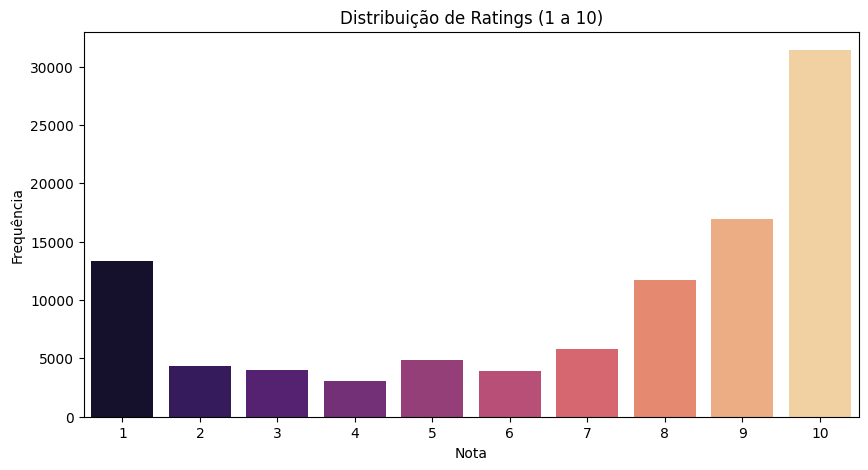

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', palette='magma')
plt.title('Distribuição de Ratings (1 a 10)')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.show()

Percebemos que as notas são polarizadas (muitos 10 e muitos 1).
Isso indica que usuários tendem a avaliar quando estão muito satisfeitos ou muito insatisfeitos.

In [ ]:
# 3. PREPARAÇÃO DOS DADOS PARA O K-MEANS (FEATURE ENGINEERING)
# ------------------------------------------------------------------------------
# Comentário: O K-Means não lê texto. Por isso, transformamos o dataset de "reviews" em um dataset de "medicamentos", agregando as métricas numéricas.
#Agrupamos por medicamento para criar o perfil de cada um
drug_features = df.groupby('drugName').agg({
    'rating': 'mean',
    'usefulCount': 'mean',
    'condition': 'nunique'  # Quantas condições diferentes este remédio trata
}).rename(columns={'rating': 'avg_rating', 'usefulCount': 'avg_utility', 'condition': 'n_conditions'})

K-Means usa distância euclidiana. Se não padronizarmos, a coluna
'usefulCount' (que vai até centenas) dominaria a 'rating' (que vai até 10).

Padronização (Scaling)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(drug_features)

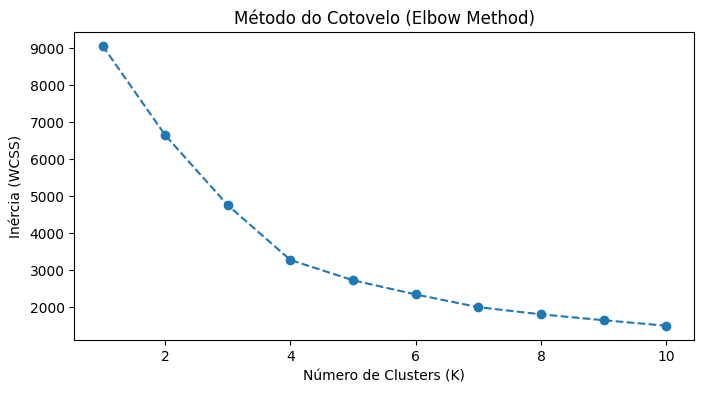

In [ ]:
# 4. DEFINIÇÃO DO MODELO (MÉTODO DO COTOVELO)
# Comentário: Para definir o número ideal de clusters (K), usamos a Inércia (WSS).

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.show()

# Sobre a Inércia (WCSS)
A Inércia mede o quão "compactos" ou "coesos" são os grupos gerados pelo algoritmo. Ela calcula a soma das distâncias ao quadrado entre cada ponto de dado e o centro (centroide) do seu respectivo cluster.

Matematicamente, a fórmula é expressa como:

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \text{dist}(x, \mu_i)^2$$

Onde:
* $k$: número de clusters.
* $C_i$: o i-ésimo cluster.
* $x$: um ponto pertencente ao cluster.
* $\mu_i$: o centroide do cluster $i$.

Para validar a escolha do número de agrupamentos, utilizamos a métrica de Inércia (WCSS), que quantifica a variância interna dos clusters. Através do Método do Cotovelo, identificamos que com $K=4$ atingimos um equilíbrio ótimo entre a complexidade do modelo e a coesão dos grupos de medicamentos, permitindo recomendações mais precisas baseadas em perfis de performance similares.

O "cotovelo" se estabiliza em K=4. Isso significa que conseguimos dividir nossos medicamentos em 4 grandes perfis de performance

In [ ]:
# 5. TREINAMENTO DA PROVA DE CONCEITO (PoC)
# ------------------------------------------------------------------------------
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
drug_features['cluster'] = kmeans_final.fit_predict(df_scaled)

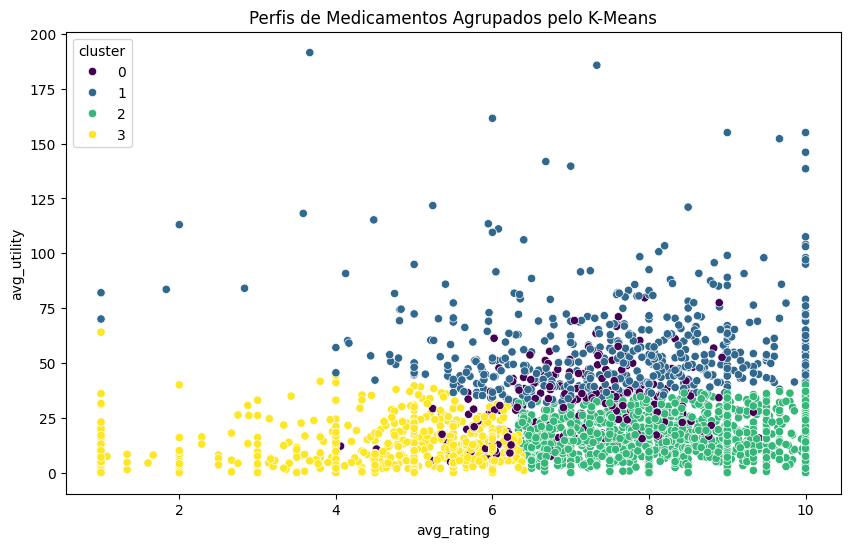

In [ ]:
# Visualização dos Perfis de Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=drug_features, x='avg_rating', y='avg_utility', hue='cluster', palette='viridis')
plt.title('Perfis de Medicamentos Agrupados pelo K-Means')
plt.show()

A lógica aqui é: "Se você quer tratar a condição X, o sistema busca no cluster de 'alta qualidade' os medicamentos que servem para essa condição".

In [ ]:
def recomendar_medicamento_poc(condicao_procurada):
    # Pegamos os medicamentos que atendem a condição
    drugs_for_condition = df[df['condition'] == condicao_procurada]['drugName'].unique()

    # Filtramos nosso dataframe de features apenas por esses remédios
    subset = drug_features.loc[drug_features.index.isin(drugs_for_condition)]

    # Recomendamos os que estão no cluster de melhor avaliação (ex: maior média de rating/utility)
    # No nosso caso, ordenamos pelo score final do cluster
    recomendacoes = subset.sort_values(by=['cluster', 'avg_rating'], ascending=False)

    return recomendacoes.head(5)

In [ ]:
# Teste de Validação da PoC
print("Testando recomendação para 'Depression':")
print(recomendar_medicamento_poc('Depression'))

Testando recomendação para 'Depression':
                 avg_rating  avg_utility  n_conditions  cluster
drugName                                                       
Paliperidone       6.072727    19.236364             4        3
Strattera          5.520000    32.608000             2        3
Fetzima            5.204082    26.714286             2        3
Levomilnacipran    5.101449    33.884058             2        3
Limbitrol         10.000000    30.000000             1        2


#1. Por que usamos K-Means?
Utilizamos o K-Means para criar uma "segmentação de qualidade". Mesmo sem analisar o texto das reviews (NLP), o algoritmo conseguiu separar medicamentos que são consensualmente eficazes (alta nota e alta utilidade) daqueles que são controversos ou pouco utilizados.

# 2. O que a Prova de Conceito validou?
Validamos que:

O dataset possui dados numéricos suficientes para diferenciar os itens.

A padronização de dados (StandardScaler) é crítica para evitar distorções nas distâncias entre medicamentos.

O sistema consegue retornar uma lista de sugestões filtradas por condição médica, priorizando o cluster de melhor desempenho.

# 3. Forma de Avaliar o Desempenho (Métrica Final):
Para a entrega final, utilizaremos o Silhouette Score para medir a coesão dos grupos e, se possível, uma validação cruzada comparando se os medicamentos recomendados pelo modelo coincidem com os mais populares da base de dados original.

# Sobre a Silhuouette Score

Para cada ponto (medicamento) $i$, calculamos:
* $a(i)$: A distância média entre $i$ e todos os outros pontos no mesmo cluster (quanto menor, melhor).

* $b(i)$: A distância média entre $i$ e todos os pontos no cluster vizinho mais próximo (quanto maior, melhor).

O coeficiente $s(i)$ é dado por:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

A média de todos os $s(i)$ do dataset é o seu Silhouette Score final.